# Hidden Emotion Detection — Custom Audio Testing Notebook

Test the trained **HiddenEmotionModel** on any audio files you supply.

**What this notebook does:**
1. Re-creates the model architecture (must match training)
2. Loads your saved checkpoints (`stage1_best.pt`, `stage2_adapters.pt`, `stage3_best.pt`)
3. Accepts custom `.wav` / `.mp3` / `.flac` / `.ogg` files (upload or path)
4. Returns:
   - **Explicit emotion** — the expressed/surface emotion (4 classes)
   - **Hidden emotion** — the suppressed/underlying emotion
   - **KL divergence score** — how strongly a hidden emotion is suspected
   - Per-frame attention heatmaps (local vs global)

> **Prerequisites:** Run this notebook in the same Google Colab session where you trained,  
> or upload your `.pt` checkpoint files to Drive / the Colab runtime.


In [ ]:
# CELL 1 — Install dependencies
!pip install transformers torchaudio torch scikit-learn matplotlib librosa -q


In [ ]:
# CELL 2 — Mount Google Drive (needed to load checkpoints saved there)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# CELL 3 — Imports & global config (must match training)
import os
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch.nn.functional as F
from torch import nn
from transformers import HubertForSequenceClassification, Wav2Vec2FeatureExtractor

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAMPLE_RATE = 16000
MAX_LENGTH  = 6 * SAMPLE_RATE       # 6 seconds — same as training

# ── 4-class label set (frustrated class was dropped in v2) ──
EMOTIONS = ['angry', 'happy', 'neutral', 'sad']
label2id = {e: i for i, e in enumerate(EMOTIONS)}
id2label = {i: e for i, e in enumerate(EMOTIONS)}

print(f'Device: {DEVICE}')
print(f'Classes: {EMOTIONS}')


Device: cpu
Classes: ['angry', 'happy', 'neutral', 'sad']


In [16]:
# CELL 4 — Model architecture (verbatim copy from training notebook)
# Must be identical to what was used during training.

class AdapterLayer(nn.Module):
    def __init__(self, hidden_size=768, bottleneck=64):
        super().__init__()
        self.down = nn.Linear(hidden_size, bottleneck)
        self.act  = nn.GELU()
        self.up   = nn.Linear(bottleneck, hidden_size)
        self.norm = nn.LayerNorm(hidden_size)
        nn.init.zeros_(self.up.weight)
        nn.init.zeros_(self.up.bias)

    def forward(self, x):
        return self.norm(x + self.up(self.act(self.down(x))))


class HuBERTWithAdapters(nn.Module):
    def __init__(self, hubert_model):
        super().__init__()
        self.hubert     = hubert_model.hubert
        self.num_layers = len(self.hubert.encoder.layers)
        self.adapters   = nn.ModuleList([AdapterLayer() for _ in range(self.num_layers)])
        for param in self.hubert.parameters():
            param.requires_grad = False

    def forward(self, input_values):
        hidden = self.hubert(input_values=input_values,
                             output_hidden_states=True).last_hidden_state
        for adapter in self.adapters:
            hidden = adapter(hidden)
        return hidden


class DualPathAttention(nn.Module):
    def __init__(self, hidden_size=768, window=4):
        super().__init__()
        self.window   = window
        self.scale    = hidden_size ** 0.5
        self.local_q  = nn.Linear(hidden_size, hidden_size)
        self.local_k  = nn.Linear(hidden_size, hidden_size)
        self.local_v  = nn.Linear(hidden_size, hidden_size)
        self.global_q = nn.Parameter(torch.randn(1, 1, hidden_size))
        self.global_k = nn.Linear(hidden_size, hidden_size)
        self.global_v = nn.Linear(hidden_size, hidden_size)
        self.norm_local  = nn.LayerNorm(hidden_size)
        self.norm_global = nn.LayerNorm(hidden_size)

    def forward(self, x):
        B, T, H = x.shape
        W = self.window
        Q = self.local_q(x)
        K = self.local_k(x)
        V = self.local_v(x)
        K_pad = F.pad(K.transpose(1, 2), (W, W)).transpose(1, 2)
        V_pad = F.pad(V.transpose(1, 2), (W, W)).transpose(1, 2)
        win_size = 2 * W + 1
        K_win = torch.stack([K_pad[:, t:t+T, :] for t in range(win_size)], dim=2)
        V_win = torch.stack([V_pad[:, t:t+T, :] for t in range(win_size)], dim=2)
        w_local      = torch.softmax(torch.einsum('bth,btwh->btw', Q, K_win) / self.scale, dim=-1)
        local_out    = torch.einsum('btw,btwh->btwh', w_local, V_win).sum(dim=2)
        local_weights = w_local.mean(dim=-1)
        local_pooled = local_out.mean(dim=1)
        gq           = self.global_q.expand(B, -1, -1)
        gk           = self.global_k(x)
        gv           = self.global_v(x)
        g_scores     = torch.bmm(gq, gk.transpose(1, 2)) / self.scale
        g_weights    = torch.softmax(g_scores, dim=-1)
        global_out   = torch.bmm(g_weights, gv).squeeze(1)
        global_weights = g_weights.squeeze(1)
        return self.norm_local(local_pooled), self.norm_global(global_out), local_weights, global_weights


class HiddenEmotionModel(nn.Module):
    def __init__(self, adapter_model, num_labels=4, hidden_size=768):
        super().__init__()
        self.encoder       = adapter_model
        self.dual_attn     = DualPathAttention(hidden_size)
        self.explicit_head = nn.Sequential(
            nn.Linear(hidden_size, 256), nn.GELU(), nn.Dropout(0.1), nn.Linear(256, num_labels)
        )
        self.hidden_head = nn.Sequential(
            nn.Linear(hidden_size, 256), nn.GELU(), nn.Dropout(0.1), nn.Linear(256, num_labels)
        )

    def forward(self, input_values):
        hidden = self.encoder(input_values)
        local_rep, global_rep, lw, gw = self.dual_attn(hidden)
        explicit_logits = self.explicit_head(global_rep)
        hidden_logits   = self.hidden_head(local_rep)
        eps       = 1e-8
        exp_probs = F.softmax(explicit_logits, dim=-1)
        hid_probs = F.softmax(hidden_logits,   dim=-1)
        kl_div = (exp_probs * ((exp_probs + eps) / (hid_probs + eps)).log()).sum(dim=-1)
        return explicit_logits, hidden_logits, kl_div, lw, gw


    def load_checkpoint(obj, name):
        local = f'/content/{name}.pt'
        drive = f'/content/drive/MyDrive/{name}.pt'
        path  = local if os.path.exists(local) else drive
        obj.load_state_dict(torch.load(path, map_location=DEVICE))
        print(f'Loaded {name}')
        return obj

print('Model classes defined ✓')


Model classes defined ✓


In [ ]:
# CELL 5 — Load checkpoints
#
# Set the paths to your saved .pt files.
# Default: looks in /content/ first, then /content/drive/MyDrive/
#
# You can also upload them manually via the Files panel on the left.

def find_checkpoint(name):
    local = f'/content/{name}.pt'
    gdrive = f'/content/drive/MyDrive/{name}.pt'
    if os.path.exists(local):
        print(f'Found {name}.pt at {local}')
        return local
    elif os.path.exists(gdrive):
        print(f'Found {name}.pt on Drive')
        return gdrive
    else:
        raise FileNotFoundError(
            f'{name}.pt not found.\n'
            f'Upload it to /content/ or place it in your Google Drive root.'
        )

# ── 1. Load base HuBERT ──
print('Loading HuBERT-base ...')
processor = Wav2Vec2FeatureExtractor.from_pretrained('facebook/hubert-base-ls960')
base_hubert = HubertForSequenceClassification.from_pretrained(
    'facebook/hubert-base-ls960',
    num_labels=len(EMOTIONS),
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True
)

# ── 2. Load Stage 1 weights into base HuBERT ──
s1_path = find_checkpoint('stage1_best')
base_hubert.load_state_dict(torch.load(s1_path, map_location=DEVICE))
base_hubert.eval()
print('Stage 1 weights loaded ✓')

# ── 3. Build adapter model and load Stage 2 adapter weights ──
adapter_model = HuBERTWithAdapters(base_hubert).to(DEVICE)
s2_path = find_checkpoint('stage2_adapters')
adapter_model.adapters.load_state_dict(torch.load(s2_path, map_location=DEVICE))
print('Stage 2 adapter weights loaded ✓')

# ── 4. Build full model and load Stage 3 weights ──
full_model = HiddenEmotionModel(adapter_model, num_labels=len(EMOTIONS)).to(DEVICE)
s3_path = find_checkpoint('stage3_best')
full_model.load_state_dict(torch.load(s3_path, map_location=DEVICE))
full_model.eval()
print('Stage 3 weights loaded ✓')
print('\nModel ready for inference.')


Loading HuBERT-base ...


preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HubertForSequenceClassification LOAD REPORT from: facebook/hubert-base-ls960
Key               | Status  | 
------------------+---------+-
projector.weight  | MISSING | 
projector.bias    | MISSING | 
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Found stage1_best.pt on Drive


model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Stage 1 weights loaded ✓
Found stage2_adapters.pt on Drive
Stage 2 adapter weights loaded ✓
Found stage3_best.pt on Drive
Stage 3 weights loaded ✓

Model ready for inference.


In [ ]:
# CELL 6 — Audio loading utility
# Accepts .wav / .mp3 / .flac / .ogg at any sample rate & channel count.

def load_audio(path: str) -> torch.Tensor:
    """Load any audio file → mono 16 kHz tensor, clipped to MAX_LENGTH."""
    wav, sr = torchaudio.load(path)
    if sr != SAMPLE_RATE:
        wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
    if wav.dim() > 1:
        wav = wav.mean(dim=0)          # stereo → mono
    wav = wav[:MAX_LENGTH]             # clip to 6 s
    if wav.abs().max() < 1e-6:
        raise ValueError(f'Audio file appears to be silent: {path}')
    return wav


def preprocess(wav: torch.Tensor) -> torch.Tensor:
    """Run the Wav2Vec2 feature extractor → model-ready input tensor."""
    inp = processor(
        wav.numpy(), sampling_rate=SAMPLE_RATE,
        return_tensors='pt', padding='max_length',
        max_length=MAX_LENGTH, truncation=True
    )
    return inp['input_values'].to(DEVICE)

print('Audio utilities ready ✓')


Audio utilities ready ✓


In [9]:
# CELL 7 — Inference on a single audio file
#
# ┌──────────────────────────────────────────┐
# │  SET YOUR AUDIO FILE PATH HERE           │
# └──────────────────────────────────────────┘
AUDIO_PATH = '/content/voice_preview_ash - conversational, kind and bright (1).wav'   # ← change this

# ── Alternatively: upload a file interactively ──
# from google.colab import files
# uploaded = files.upload()
# AUDIO_PATH = list(uploaded.keys())[0]

# ── Inference ──
wav = load_audio(AUDIO_PATH)
iv  = preprocess(wav).unsqueeze(0) if preprocess(wav).dim() == 1 else preprocess(wav)

# Ensure batch dimension
if iv.dim() == 1:
    iv = iv.unsqueeze(0)

with torch.no_grad():
    exp_logits, hid_logits, kl_div, local_weights, global_weights = full_model(iv)

exp_probs = torch.softmax(exp_logits, dim=-1).squeeze().cpu().numpy()
hid_probs = torch.softmax(hid_logits, dim=-1).squeeze().cpu().numpy()
kl_score  = kl_div.item()

exp_pred = EMOTIONS[exp_probs.argmax()]
hid_pred = EMOTIONS[hid_probs.argmax()]

# KL threshold calibrated on IEMOCAP (mean+1std ≈ ~0.15–0.30 depending on run)
# Adjust CALIBRATION_KL to the threshold printed at the end of your training Cell 11.
CALIBRATION_KL = 0.25    # ← set this to your trained model's kl_mean_std value

print('=' * 55)
print(f'  File             : {os.path.basename(AUDIO_PATH)}')
print(f'  Duration (s)     : {wav.shape[0] / SAMPLE_RATE:.2f}')
print('=' * 55)
print(f'  Expressed emotion: {exp_pred.upper():10s}  (confidence {exp_probs.max():.2%})')
print(f'  Suppressed emot. : {hid_pred.upper():10s}  (confidence {hid_probs.max():.2%})')
print(f'  KL divergence    : {kl_score:.4f}  (threshold = {CALIBRATION_KL:.4f})')
if kl_score > CALIBRATION_KL:
    print(f'  ⚠  Hidden emotion SUSPECTED  (KL > threshold)')
    if exp_pred != hid_pred:
        print(f'     Expressed: {exp_pred}  →  Suppressed: {hid_pred}')
    else:
        print(f'     Both heads agree on emotion, but high uncertainty overall.')
else:
    print(f'  ✓  No strong suppression signal detected.')
print('=' * 55)

print('\nPer-class probabilities:')
print(f'  {"Emotion":12s}  {"Expressed":>10s}  {"Suppressed":>10s}')
for i, emo in enumerate(EMOTIONS):
    marker = ' ←' if emo == exp_pred or emo == hid_pred else ''
    print(f'  {emo:12s}  {exp_probs[i]:>10.3f}  {hid_probs[i]:>10.3f}{marker}')


  File             : voice_preview_ash - conversational, kind and bright (1).wav
  Duration (s)     : 6.00
  Expressed emotion: NEUTRAL     (confidence 94.01%)
  Suppressed emot. : NEUTRAL     (confidence 95.97%)
  KL divergence    : 0.0055  (threshold = 0.2500)
  ✓  No strong suppression signal detected.

Per-class probabilities:
  Emotion        Expressed  Suppressed
  angry              0.019       0.010
  happy              0.020       0.013
  neutral            0.940       0.960 ←
  sad                0.021       0.017


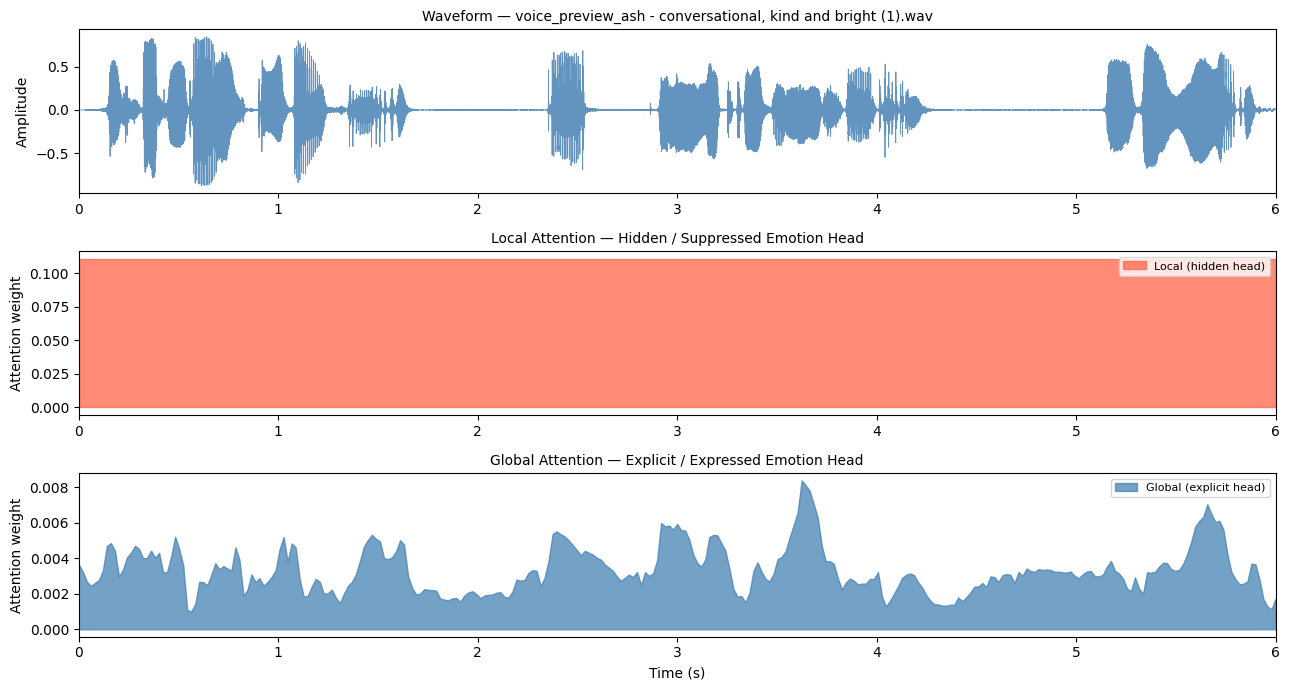

Attention heatmap saved to /content/attention_heatmap.png


In [10]:
# CELL 8 — Attention heatmap (local vs global over time)
#
# local_weights  → per-frame importance for HIDDEN head (suppressed emotion)
# global_weights → per-frame importance for EXPLICIT head (expressed emotion)
#
# Run CELL 7 first so local_weights and global_weights are defined.

import librosa
import librosa.display

wav_np = wav.cpu().numpy()

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=False)

# Row 0: waveform
t_audio = np.linspace(0, len(wav_np) / SAMPLE_RATE, len(wav_np))
axes[0].plot(t_audio, wav_np, color='steelblue', linewidth=0.6, alpha=0.85)
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Waveform — {os.path.basename(AUDIO_PATH)}', fontsize=10)
axes[0].set_xlim(0, t_audio[-1])

# Row 1: local attention (hidden head)
lw_np = local_weights.squeeze(0).cpu().numpy()          # shape (T_frames,)
t_frames = np.linspace(0, len(wav_np) / SAMPLE_RATE, len(lw_np))
axes[1].fill_between(t_frames, lw_np, alpha=0.75, color='tomato', label='Local (hidden head)')
axes[1].set_ylabel('Attention weight')
axes[1].set_title('Local Attention — Hidden / Suppressed Emotion Head', fontsize=10)
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_xlim(0, t_frames[-1])

# Row 2: global attention (explicit head)
gw_np = global_weights.squeeze(0).cpu().numpy()         # shape (T_frames,)
axes[2].fill_between(t_frames, gw_np, alpha=0.75, color='steelblue', label='Global (explicit head)')
axes[2].set_ylabel('Attention weight')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Global Attention — Explicit / Expressed Emotion Head', fontsize=10)
axes[2].legend(loc='upper right', fontsize=8)
axes[2].set_xlim(0, t_frames[-1])

plt.tight_layout()
plt.savefig('/content/attention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Attention heatmap saved to /content/attention_heatmap.png')


In [22]:
# CELL 7 — Inference on a single audio file
#
# ┌──────────────────────────────────────────┐
# │  SET YOUR AUDIO FILE PATH HERE           │
# └──────────────────────────────────────────┘
AUDIO_PATH = '/content/voice_preview_mr. claus – the classic jolly santa (1).wav'   # ← change this

# ── Alternatively: upload a file interactively ──
# from google.colab import files
# uploaded = files.upload()
# AUDIO_PATH = list(uploaded.keys())[0]

# ── Inference ──
wav = load_audio(AUDIO_PATH)
iv  = preprocess(wav).unsqueeze(0) if preprocess(wav).dim() == 1 else preprocess(wav)

# Ensure batch dimension
if iv.dim() == 1:
    iv = iv.unsqueeze(0)

with torch.no_grad():
    exp_logits, hid_logits, kl_div, local_weights, global_weights = full_model(iv)

exp_probs = torch.softmax(exp_logits, dim=-1).squeeze().cpu().numpy()
hid_probs = torch.softmax(hid_logits, dim=-1).squeeze().cpu().numpy()
kl_score  = kl_div.item()

exp_pred = EMOTIONS[exp_probs.argmax()]
hid_pred = EMOTIONS[hid_probs.argmax()]

# KL threshold calibrated on IEMOCAP (mean+1std ≈ ~0.15–0.30 depending on run)
# Adjust CALIBRATION_KL to the threshold printed at the end of your training Cell 11.
CALIBRATION_KL = 0.25    # ← set this to your trained model's kl_mean_std value

print('=' * 55)
print(f'  File             : {os.path.basename(AUDIO_PATH)}')
print(f'  Duration (s)     : {wav.shape[0] / SAMPLE_RATE:.2f}')
print('=' * 55)
print(f'  Expressed emotion: {exp_pred.upper():10s}  (confidence {exp_probs.max():.2%})')
print(f'  Suppressed emot. : {hid_pred.upper():10s}  (confidence {hid_probs.max():.2%})')
print(f'  KL divergence    : {kl_score:.4f}  (threshold = {CALIBRATION_KL:.4f})')
if kl_score > CALIBRATION_KL:
    print(f'  ⚠  Hidden emotion SUSPECTED  (KL > threshold)')
    if exp_pred != hid_pred:
        print(f'     Expressed: {exp_pred}  →  Suppressed: {hid_pred}')
    else:
        print(f'     Both heads agree on emotion, but high uncertainty overall.')
else:
    print(f'  ✓  No strong suppression signal detected.')
print('=' * 55)

print('\nPer-class probabilities:')
print(f'  {"Emotion":12s}  {"Expressed":>10s}  {"Suppressed":>10s}')
for i, emo in enumerate(EMOTIONS):
    marker = ' ←' if emo == exp_pred or emo == hid_pred else ''
    print(f'  {emo:12s}  {exp_probs[i]:>10.3f}  {hid_probs[i]:>10.3f}{marker}')


  File             : voice_preview_mr. claus – the classic jolly santa (1).wav
  Duration (s)     : 6.00
  Expressed emotion: ANGRY       (confidence 95.53%)
  Suppressed emot. : ANGRY       (confidence 95.07%)
  KL divergence    : 0.0003  (threshold = 0.2500)
  ✓  No strong suppression signal detected.

Per-class probabilities:
  Emotion        Expressed  Suppressed
  angry              0.955       0.951 ←
  happy              0.012       0.012
  neutral            0.018       0.020
  sad                0.015       0.017


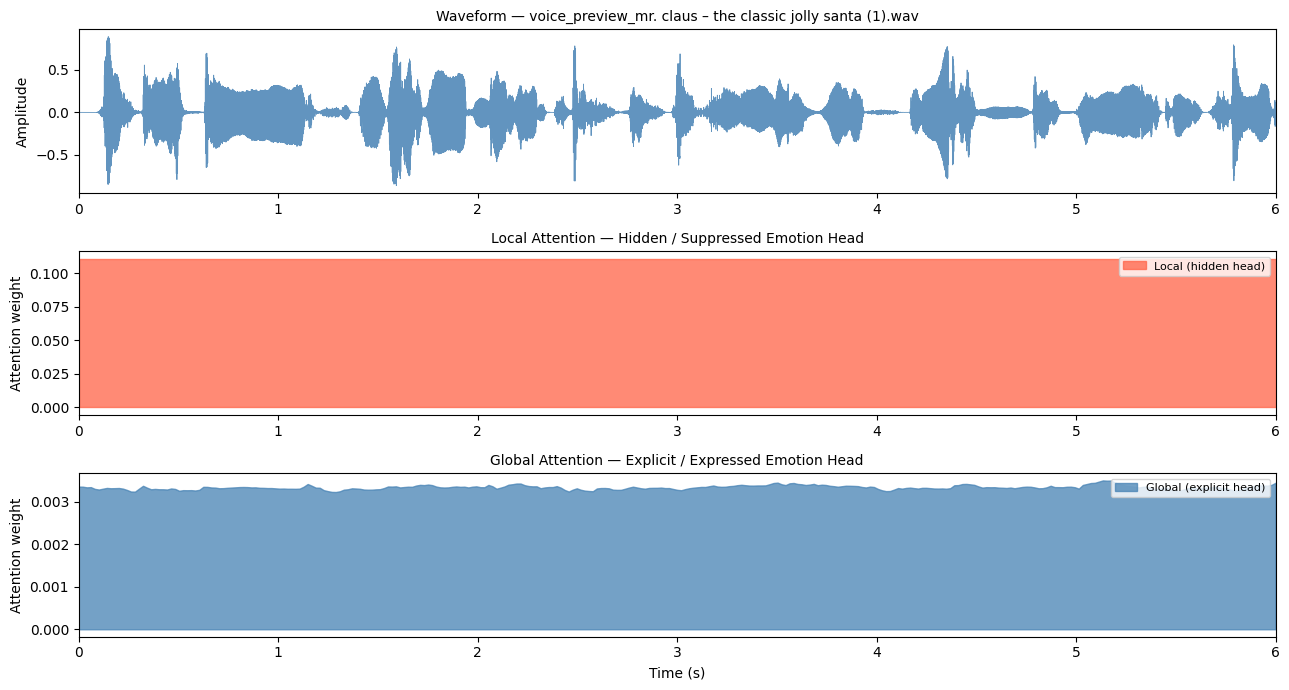

Attention heatmap saved to /content/attention_heatmap.png


In [23]:
# CELL 8 — Attention heatmap (local vs global over time)
#
# local_weights  → per-frame importance for HIDDEN head (suppressed emotion)
# global_weights → per-frame importance for EXPLICIT head (expressed emotion)
#
# Run CELL 7 first so local_weights and global_weights are defined.

import librosa
import librosa.display

wav_np = wav.cpu().numpy()

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=False)

# Row 0: waveform
t_audio = np.linspace(0, len(wav_np) / SAMPLE_RATE, len(wav_np))
axes[0].plot(t_audio, wav_np, color='steelblue', linewidth=0.6, alpha=0.85)
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Waveform — {os.path.basename(AUDIO_PATH)}', fontsize=10)
axes[0].set_xlim(0, t_audio[-1])

# Row 1: local attention (hidden head)
lw_np = local_weights.squeeze(0).cpu().numpy()          # shape (T_frames,)
t_frames = np.linspace(0, len(wav_np) / SAMPLE_RATE, len(lw_np))
axes[1].fill_between(t_frames, lw_np, alpha=0.75, color='tomato', label='Local (hidden head)')
axes[1].set_ylabel('Attention weight')
axes[1].set_title('Local Attention — Hidden / Suppressed Emotion Head', fontsize=10)
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_xlim(0, t_frames[-1])

# Row 2: global attention (explicit head)
gw_np = global_weights.squeeze(0).cpu().numpy()         # shape (T_frames,)
axes[2].fill_between(t_frames, gw_np, alpha=0.75, color='steelblue', label='Global (explicit head)')
axes[2].set_ylabel('Attention weight')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Global Attention — Explicit / Expressed Emotion Head', fontsize=10)
axes[2].legend(loc='upper right', fontsize=8)
axes[2].set_xlim(0, t_frames[-1])

plt.tight_layout()
plt.savefig('/content/attention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Attention heatmap saved to /content/attention_heatmap.png')


In [28]:
import io
import matplotlib.pyplot as plt
import numpy as np
import torchaudio
import torchaudio.transforms as TAT
import IPython.display as ipd
from google.colab import files as colab_files

def run_inference(filename, raw_bytes):
    # ── Decode & resample ──
    wav, sr = torchaudio.load(io.BytesIO(raw_bytes))
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != SAMPLE_RATE:
        wav = TAT.Resample(orig_freq=sr, new_freq=SAMPLE_RATE)(wav)
        sr  = SAMPLE_RATE

    duration_s = wav.shape[-1] / sr
    wav_np     = wav.squeeze().numpy()

    # ── Play ──
    print(f"\n{'═'*55}")
    print(f"  File: {filename}  ({duration_s:.2f} s)")
    print(f"{'═'*55}")
    ipd.display(ipd.Audio(wav_np, rate=sr))

    # ── Preprocess ──
    wav_norm = (wav_np - wav_np.mean()) / (wav_np.std() + 1e-8)
    inp = processor(
        wav_norm, sampling_rate=SAMPLE_RATE,
        return_tensors='pt', padding='max_length',
        max_length=MAX_LENGTH, truncation=True,
        return_attention_mask=True
    )
    iv    = inp['input_values'].to(DEVICE)
    amask = inp['attention_mask'].to(DEVICE)

    # ── Inference ──
    full_model.eval()
    with torch.no_grad():
        exp_logits, hid_logits, kl_div, _, _ = full_model(iv)

    exp_probs = torch.softmax(exp_logits, dim=-1).squeeze().cpu().numpy()
    hid_probs = torch.softmax(hid_logits, dim=-1).squeeze().cpu().numpy()
    kl_score  = kl_div.item()
    exp_pred  = EMOTIONS[exp_probs.argmax()]
    hid_pred  = EMOTIONS[hid_probs.argmax()]

    CALIBRATION_KL = 0.25  # ← set to kl_mean_std from Cell 11

    # ── Results ──
    print(f"  Duration (s)     : {duration_s:.2f}")
    print(f"  Expressed emotion: {exp_pred.upper():10s}  (confidence {exp_probs.max():.2%})")
    print(f"  Suppressed emot. : {hid_pred.upper():10s}  (confidence {hid_probs.max():.2%})")
    print(f"  KL divergence    : {kl_score:.4f}  (threshold = {CALIBRATION_KL:.4f})")
    if kl_score > CALIBRATION_KL:
        print(f"  ⚠  Hidden emotion SUSPECTED  (KL > threshold)")
        if exp_pred != hid_pred:
            print(f"     Expressed: {exp_pred}  →  Suppressed: {hid_pred}")
        else:
            print(f"     Both heads agree on emotion, but high uncertainty overall.")
    else:
        print(f"  ✓  No strong suppression signal detected.")
    print(f"{'═'*55}")

    print(f"\n  {'Emotion':12s}  {'Expressed':>10s}  {'Suppressed':>10s}")
    for i, emo in enumerate(EMOTIONS):
        if emo == exp_pred and emo == hid_pred: tag = ' ← both'
        elif emo == exp_pred:                   tag = ' ← expressed'
        elif emo == hid_pred:                   tag = ' ← suppressed'
        else:                                   tag = ''
        print(f"  {emo:12s}  {exp_probs[i]:>10.3f}  {hid_probs[i]:>10.3f}{tag}")


# ── Upload & run ───────────────────────────────────────────────
print("Upload one or more audio files (.wav .mp3 .m4a .flac):")
uploaded = colab_files.upload()

if not uploaded:
    raise RuntimeError("No files uploaded.")

for filename, raw_bytes in uploaded.items():
    run_inference(filename, raw_bytes)

Upload one or more audio files (.wav .mp3 .m4a .flac):


Saving test01_20s.wav to test01_20s (2).wav
Saving voice_preview_mr. claus – the classic jolly santa.wav to voice_preview_mr. claus – the classic jolly santa (10).wav
Saving voice_preview_ash - conversational, kind and bright (1).wav to voice_preview_ash - conversational, kind and bright (1) (10).wav

═══════════════════════════════════════════════════════
  File: test01_20s (2).wav  (24.00 s)
═══════════════════════════════════════════════════════


  Duration (s)     : 24.00
  Expressed emotion: SAD         (confidence 64.30%)
  Suppressed emot. : SAD         (confidence 69.04%)
  KL divergence    : 0.0071  (threshold = 0.2500)
  ✓  No strong suppression signal detected.
═══════════════════════════════════════════════════════

  Emotion        Expressed  Suppressed
  angry              0.022       0.023
  happy              0.312       0.259
  neutral            0.023       0.028
  sad                0.643       0.690 ← both

═══════════════════════════════════════════════════════
  File: voice_preview_mr. claus – the classic jolly santa (10).wav  (9.98 s)
═══════════════════════════════════════════════════════


  Duration (s)     : 9.98
  Expressed emotion: ANGRY       (confidence 95.53%)
  Suppressed emot. : ANGRY       (confidence 95.07%)
  KL divergence    : 0.0003  (threshold = 0.2500)
  ✓  No strong suppression signal detected.
═══════════════════════════════════════════════════════

  Emotion        Expressed  Suppressed
  angry              0.955       0.951 ← both
  happy              0.012       0.012
  neutral            0.018       0.020
  sad                0.015       0.017

═══════════════════════════════════════════════════════
  File: voice_preview_ash - conversational, kind and bright (1) (10).wav  (9.80 s)
═══════════════════════════════════════════════════════


  Duration (s)     : 9.80
  Expressed emotion: NEUTRAL     (confidence 94.01%)
  Suppressed emot. : NEUTRAL     (confidence 95.97%)
  KL divergence    : 0.0055  (threshold = 0.2500)
  ✓  No strong suppression signal detected.
═══════════════════════════════════════════════════════

  Emotion        Expressed  Suppressed
  angry              0.019       0.010
  happy              0.020       0.013
  neutral            0.940       0.960 ← both
  sad                0.021       0.017


In [29]:
import io
import matplotlib.pyplot as plt
import numpy as np
import torchaudio
import torchaudio.transforms as TAT
import IPython.display as ipd
from google.colab import files as colab_files

def run_inference(filename, raw_bytes):
    # ── Decode & resample ──
    wav, sr = torchaudio.load(io.BytesIO(raw_bytes))
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != SAMPLE_RATE:
        wav = TAT.Resample(orig_freq=sr, new_freq=SAMPLE_RATE)(wav)
        sr  = SAMPLE_RATE

    duration_s = wav.shape[-1] / sr
    wav_np     = wav.squeeze().numpy()

    # ── Play ──
    print(f"\n{'═'*55}")
    print(f"  File: {filename}  ({duration_s:.2f} s)")
    print(f"{'═'*55}")
    ipd.display(ipd.Audio(wav_np, rate=sr))

    # ── Preprocess ──
    wav_norm = (wav_np - wav_np.mean()) / (wav_np.std() + 1e-8)
    inp = processor(
        wav_norm, sampling_rate=SAMPLE_RATE,
        return_tensors='pt', padding='max_length',
        max_length=MAX_LENGTH, truncation=True,
        return_attention_mask=True
    )
    iv    = inp['input_values'].to(DEVICE)
    amask = inp['attention_mask'].to(DEVICE)

    # ── Inference ──
    full_model.eval()
    with torch.no_grad():
        exp_logits, hid_logits, kl_div, _, _ = full_model(iv)

    exp_probs = torch.softmax(exp_logits, dim=-1).squeeze().cpu().numpy()
    hid_probs = torch.softmax(hid_logits, dim=-1).squeeze().cpu().numpy()
    kl_score  = kl_div.item()
    exp_pred  = EMOTIONS[exp_probs.argmax()]
    hid_pred  = EMOTIONS[hid_probs.argmax()]

    CALIBRATION_KL = 0.25  # ← set to kl_mean_std from Cell 11

    # ── Results ──
    print(f"  Duration (s)     : {duration_s:.2f}")
    print(f"  Expressed emotion: {exp_pred.upper():10s}  (confidence {exp_probs.max():.2%})")
    print(f"  Suppressed emot. : {hid_pred.upper():10s}  (confidence {hid_probs.max():.2%})")
    print(f"  KL divergence    : {kl_score:.4f}  (threshold = {CALIBRATION_KL:.4f})")
    if kl_score > CALIBRATION_KL:
        print(f"  ⚠  Hidden emotion SUSPECTED  (KL > threshold)")
        if exp_pred != hid_pred:
            print(f"     Expressed: {exp_pred}  →  Suppressed: {hid_pred}")
        else:
            print(f"     Both heads agree on emotion, but high uncertainty overall.")
    else:
        print(f"  ✓  No strong suppression signal detected.")
    print(f"{'═'*55}")

    print(f"\n  {'Emotion':12s}  {'Expressed':>10s}  {'Suppressed':>10s}")
    for i, emo in enumerate(EMOTIONS):
        if emo == exp_pred and emo == hid_pred: tag = ' ← both'
        elif emo == exp_pred:                   tag = ' ← expressed'
        elif emo == hid_pred:                   tag = ' ← suppressed'
        else:                                   tag = ''
        print(f"  {emo:12s}  {exp_probs[i]:>10.3f}  {hid_probs[i]:>10.3f}{tag}")


# ── Upload & run ───────────────────────────────────────────────
print("Upload one or more audio files (.wav .mp3 .m4a .flac):")
uploaded = colab_files.upload()

if not uploaded:
    raise RuntimeError("No files uploaded.")

for filename, raw_bytes in uploaded.items():
    run_inference(filename, raw_bytes)

Upload one or more audio files (.wav .mp3 .m4a .flac):


Saving WhatsApp Audio 2026-04-23 at 10.30.31 AM.wav to WhatsApp Audio 2026-04-23 at 10.30.31 AM.wav
Saving WhatsApp Audio 2026-04-23 at 10.30.32 AM.wav to WhatsApp Audio 2026-04-23 at 10.30.32 AM.wav
Saving WhatsApp Audio 2026-04-23 at 10.30.33 AM.wav to WhatsApp Audio 2026-04-23 at 10.30.33 AM.wav
Saving WhatsApp Audio 2026-04-23 at 10.30.30 AM.wav to WhatsApp Audio 2026-04-23 at 10.30.30 AM.wav
Saving WhatsApp Audio 2026-04-23 at 10.30.26 AM.wav to WhatsApp Audio 2026-04-23 at 10.30.26 AM.wav

═══════════════════════════════════════════════════════
  File: WhatsApp Audio 2026-04-23 at 10.30.31 AM.wav  (6.19 s)
═══════════════════════════════════════════════════════


  Duration (s)     : 6.19
  Expressed emotion: SAD         (confidence 91.63%)
  Suppressed emot. : SAD         (confidence 90.85%)
  KL divergence    : 0.0007  (threshold = 0.2500)
  ✓  No strong suppression signal detected.
═══════════════════════════════════════════════════════

  Emotion        Expressed  Suppressed
  angry              0.013       0.012
  happy              0.028       0.029
  neutral            0.042       0.050
  sad                0.916       0.908 ← both

═══════════════════════════════════════════════════════
  File: WhatsApp Audio 2026-04-23 at 10.30.32 AM.wav  (3.75 s)
═══════════════════════════════════════════════════════


  Duration (s)     : 3.75
  Expressed emotion: NEUTRAL     (confidence 86.14%)
  Suppressed emot. : NEUTRAL     (confidence 87.36%)
  KL divergence    : 0.0016  (threshold = 0.2500)
  ✓  No strong suppression signal detected.
═══════════════════════════════════════════════════════

  Emotion        Expressed  Suppressed
  angry              0.017       0.011
  happy              0.025       0.022
  neutral            0.861       0.874 ← both
  sad                0.097       0.093

═══════════════════════════════════════════════════════
  File: WhatsApp Audio 2026-04-23 at 10.30.33 AM.wav  (3.16 s)
═══════════════════════════════════════════════════════


  Duration (s)     : 3.16
  Expressed emotion: NEUTRAL     (confidence 93.31%)
  Suppressed emot. : NEUTRAL     (confidence 95.27%)
  KL divergence    : 0.0040  (threshold = 0.2500)
  ✓  No strong suppression signal detected.
═══════════════════════════════════════════════════════

  Emotion        Expressed  Suppressed
  angry              0.021       0.013
  happy              0.034       0.026
  neutral            0.933       0.953 ← both
  sad                0.012       0.008

═══════════════════════════════════════════════════════
  File: WhatsApp Audio 2026-04-23 at 10.30.30 AM.wav  (5.44 s)
═══════════════════════════════════════════════════════


  Duration (s)     : 5.44
  Expressed emotion: SAD         (confidence 92.90%)
  Suppressed emot. : SAD         (confidence 92.63%)
  KL divergence    : 0.0003  (threshold = 0.2500)
  ✓  No strong suppression signal detected.
═══════════════════════════════════════════════════════

  Emotion        Expressed  Suppressed
  angry              0.013       0.012
  happy              0.020       0.020
  neutral            0.038       0.042
  sad                0.929       0.926 ← both

═══════════════════════════════════════════════════════
  File: WhatsApp Audio 2026-04-23 at 10.30.26 AM.wav  (3.67 s)
═══════════════════════════════════════════════════════


  Duration (s)     : 3.67
  Expressed emotion: SAD         (confidence 76.99%)
  Suppressed emot. : SAD         (confidence 76.18%)
  KL divergence    : 0.0007  (threshold = 0.2500)
  ✓  No strong suppression signal detected.
═══════════════════════════════════════════════════════

  Emotion        Expressed  Suppressed
  angry              0.017       0.014
  happy              0.031       0.030
  neutral            0.182       0.194
  sad                0.770       0.762 ← both
